In [1]:
from src.config import *
from src.data_loader import *
from src.utils import *

In [2]:
%run src/data_loader.py

init_duckdb_views()
show_database_schema()

Created or replaced view: author
Created or replaced view: reason
Created or replaced view: retraction
Created or replaced view: retraction_author
Created or replaced view: retraction_reason
Created or replaced view: retraction_subject
Completed automatic creation of all views.
Table/View: author
  - author_id (VARCHAR)
  - author_name (VARCHAR)

Table/View: reason
  - reason_tag (VARCHAR)
  - reason_category (VARCHAR)

Table/View: retraction
  - doi (VARCHAR)
  - publication_date (TIMESTAMP_NS)
  - retraction_date (TIMESTAMP_NS)
  - journal (VARCHAR)
  - publisher (VARCHAR)
  - retraction_lag_days (BIGINT)

Table/View: retraction_author
  - doi (VARCHAR)
  - author_id (VARCHAR)
  - is_1st_author (BOOLEAN)
  - affiliation_country (VARCHAR)

Table/View: retraction_reason
  - doi (VARCHAR)
  - reason_tag (VARCHAR)

Table/View: retraction_subject
  - doi (VARCHAR)
  - subject (VARCHAR)

Completed displaying database schema information.


In [50]:
retraction_by_authorship_sql = load_yaml_file(SQL_DIR / "year-wise-pattern.yaml").get("sql")
retraction_by_authorship = execute_sql_to_df(retraction_by_authorship_sql)
retraction_by_authorship

,retraction_year,1 author,2 authors,3 authors,4+ authors
0,2021,5,2,0,1
1,2022,36,23,13,7
2,2023,124,84,43,24
3,2024,22,14,8,6
4,2025,9,6,5,3
5,2026,9,5,1,0


Done


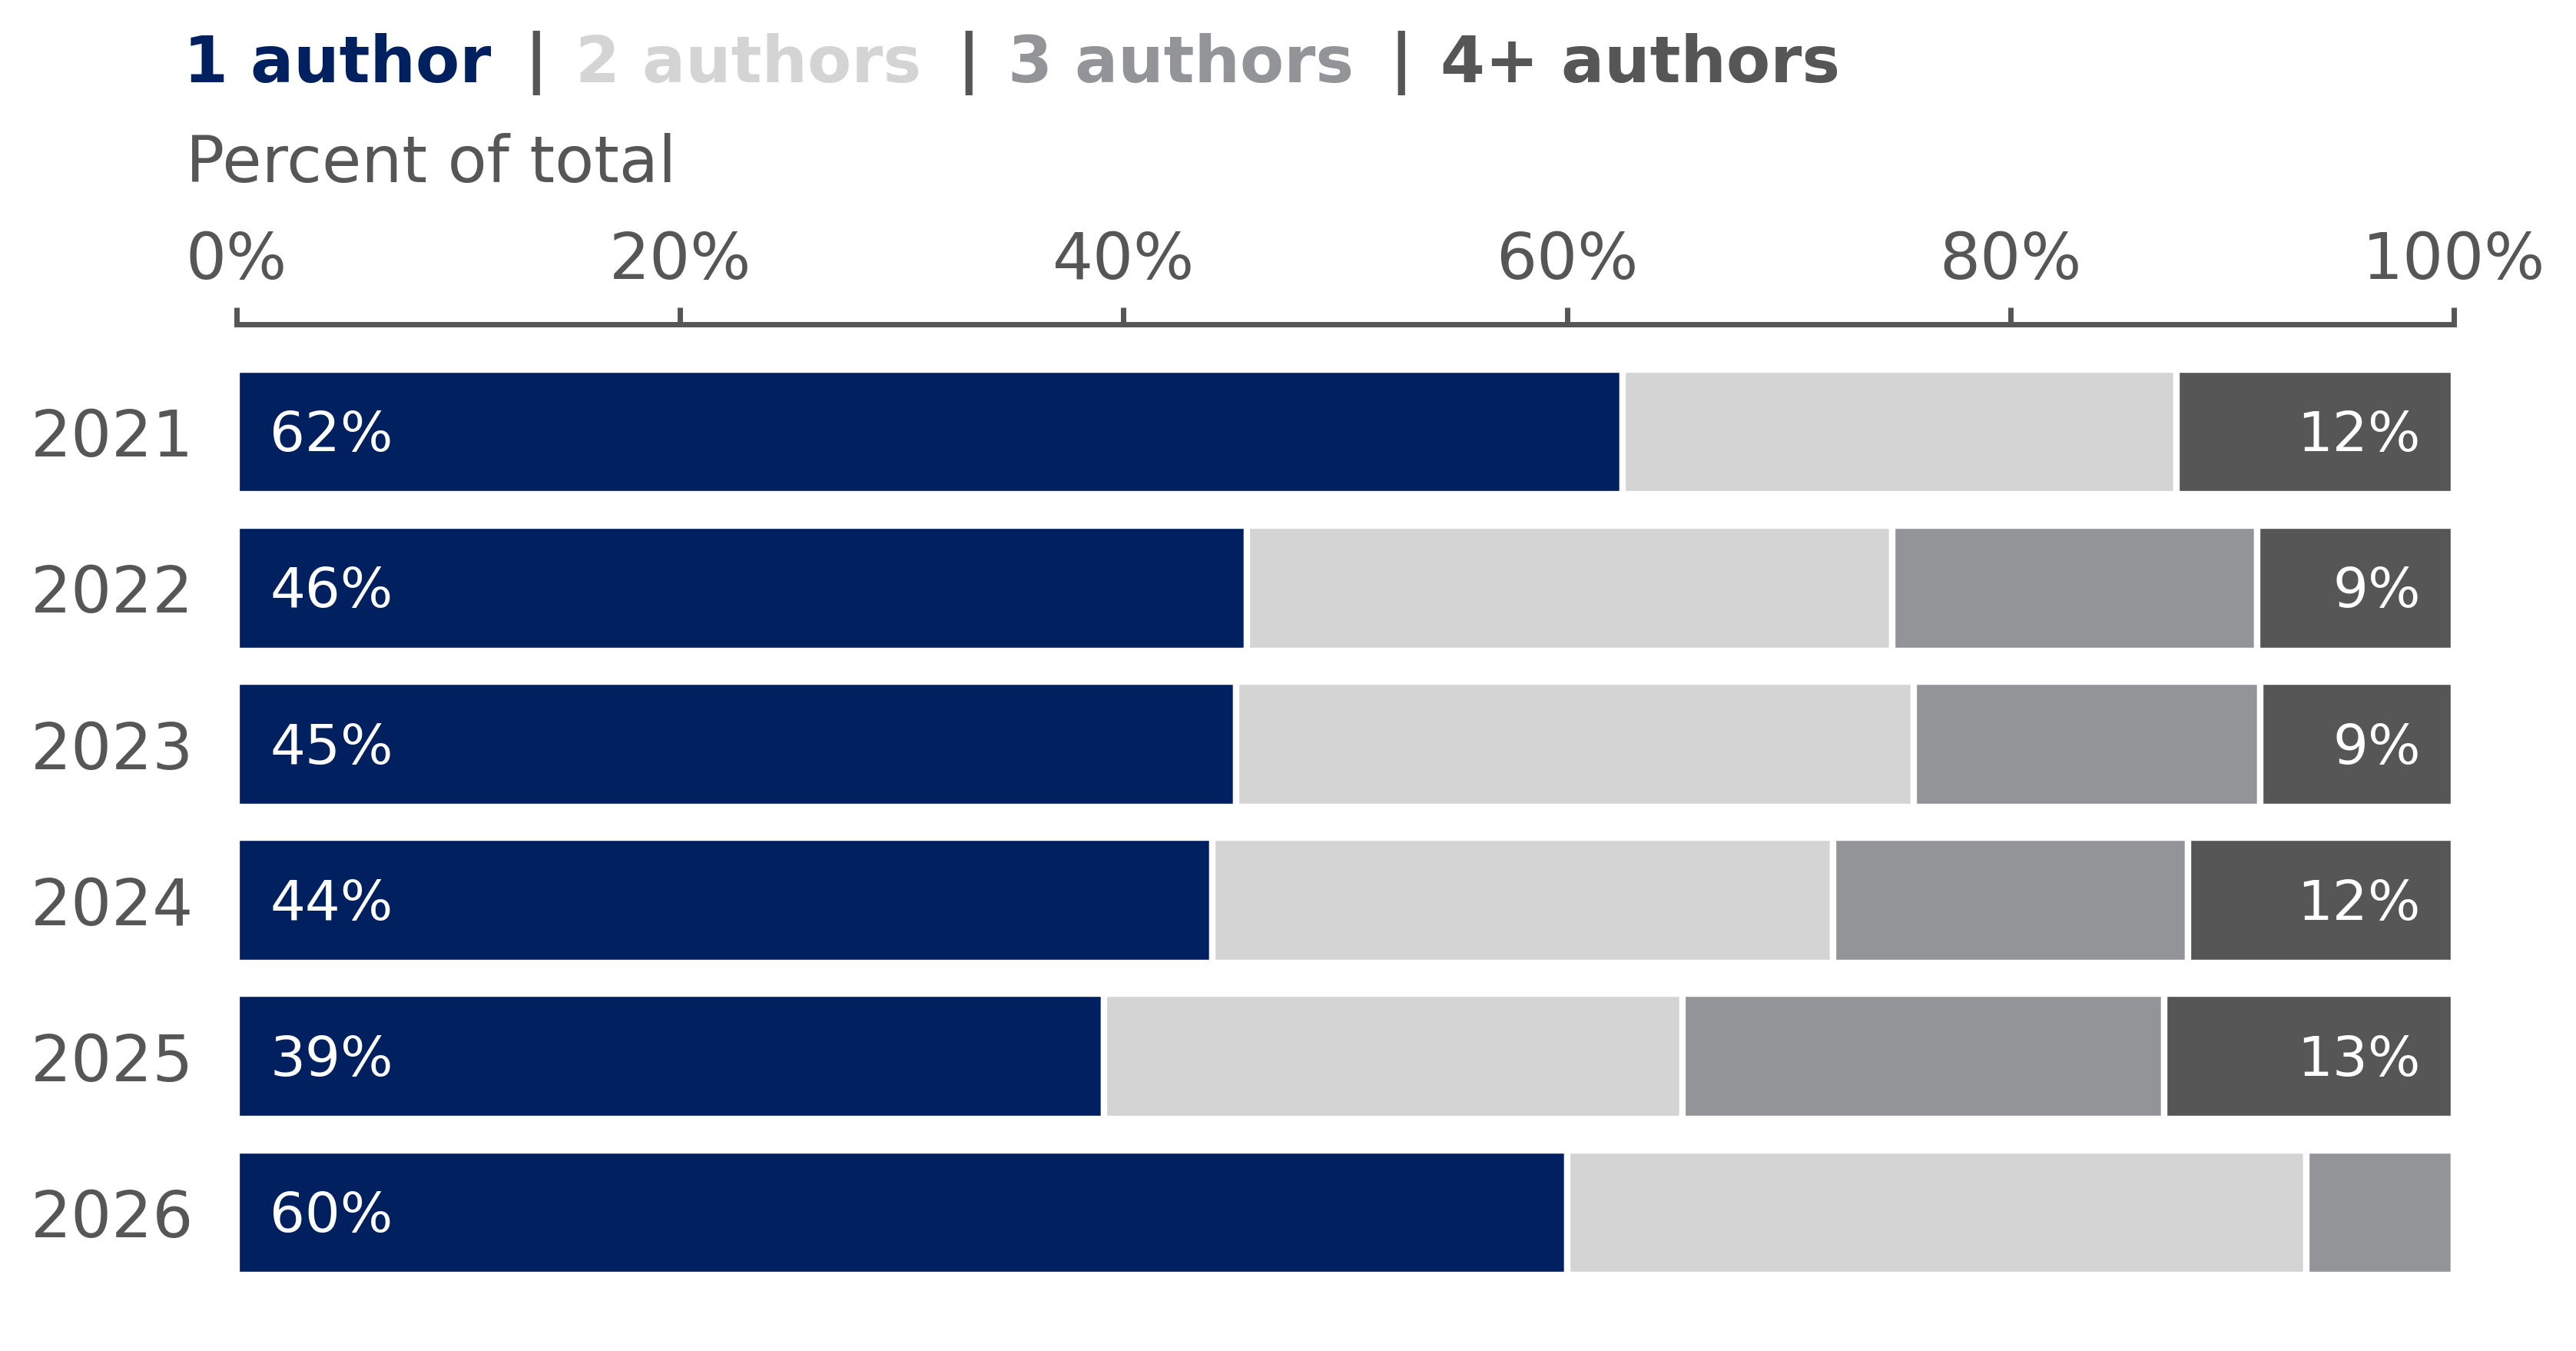

In [53]:
%run src/plotting_styles.py
%run src/plots/year-wise-pattern.py

fig, ax = render_authorship_distribution_chart(
    df=retraction_by_authorship,
    palette=PALETTE,
)

plt.show()

In [56]:
retraction_by_year_sql = load_yaml_file(SQL_DIR / "volume-by-year.yaml").get("sql")
retraction_by_year = execute_sql_to_df(retraction_by_year_sql)
retraction_by_year

,retraction_year,retraction_count
0,2021,9
1,2022,82
2,2023,307
3,2024,61
4,2025,26
5,2026,16


Done


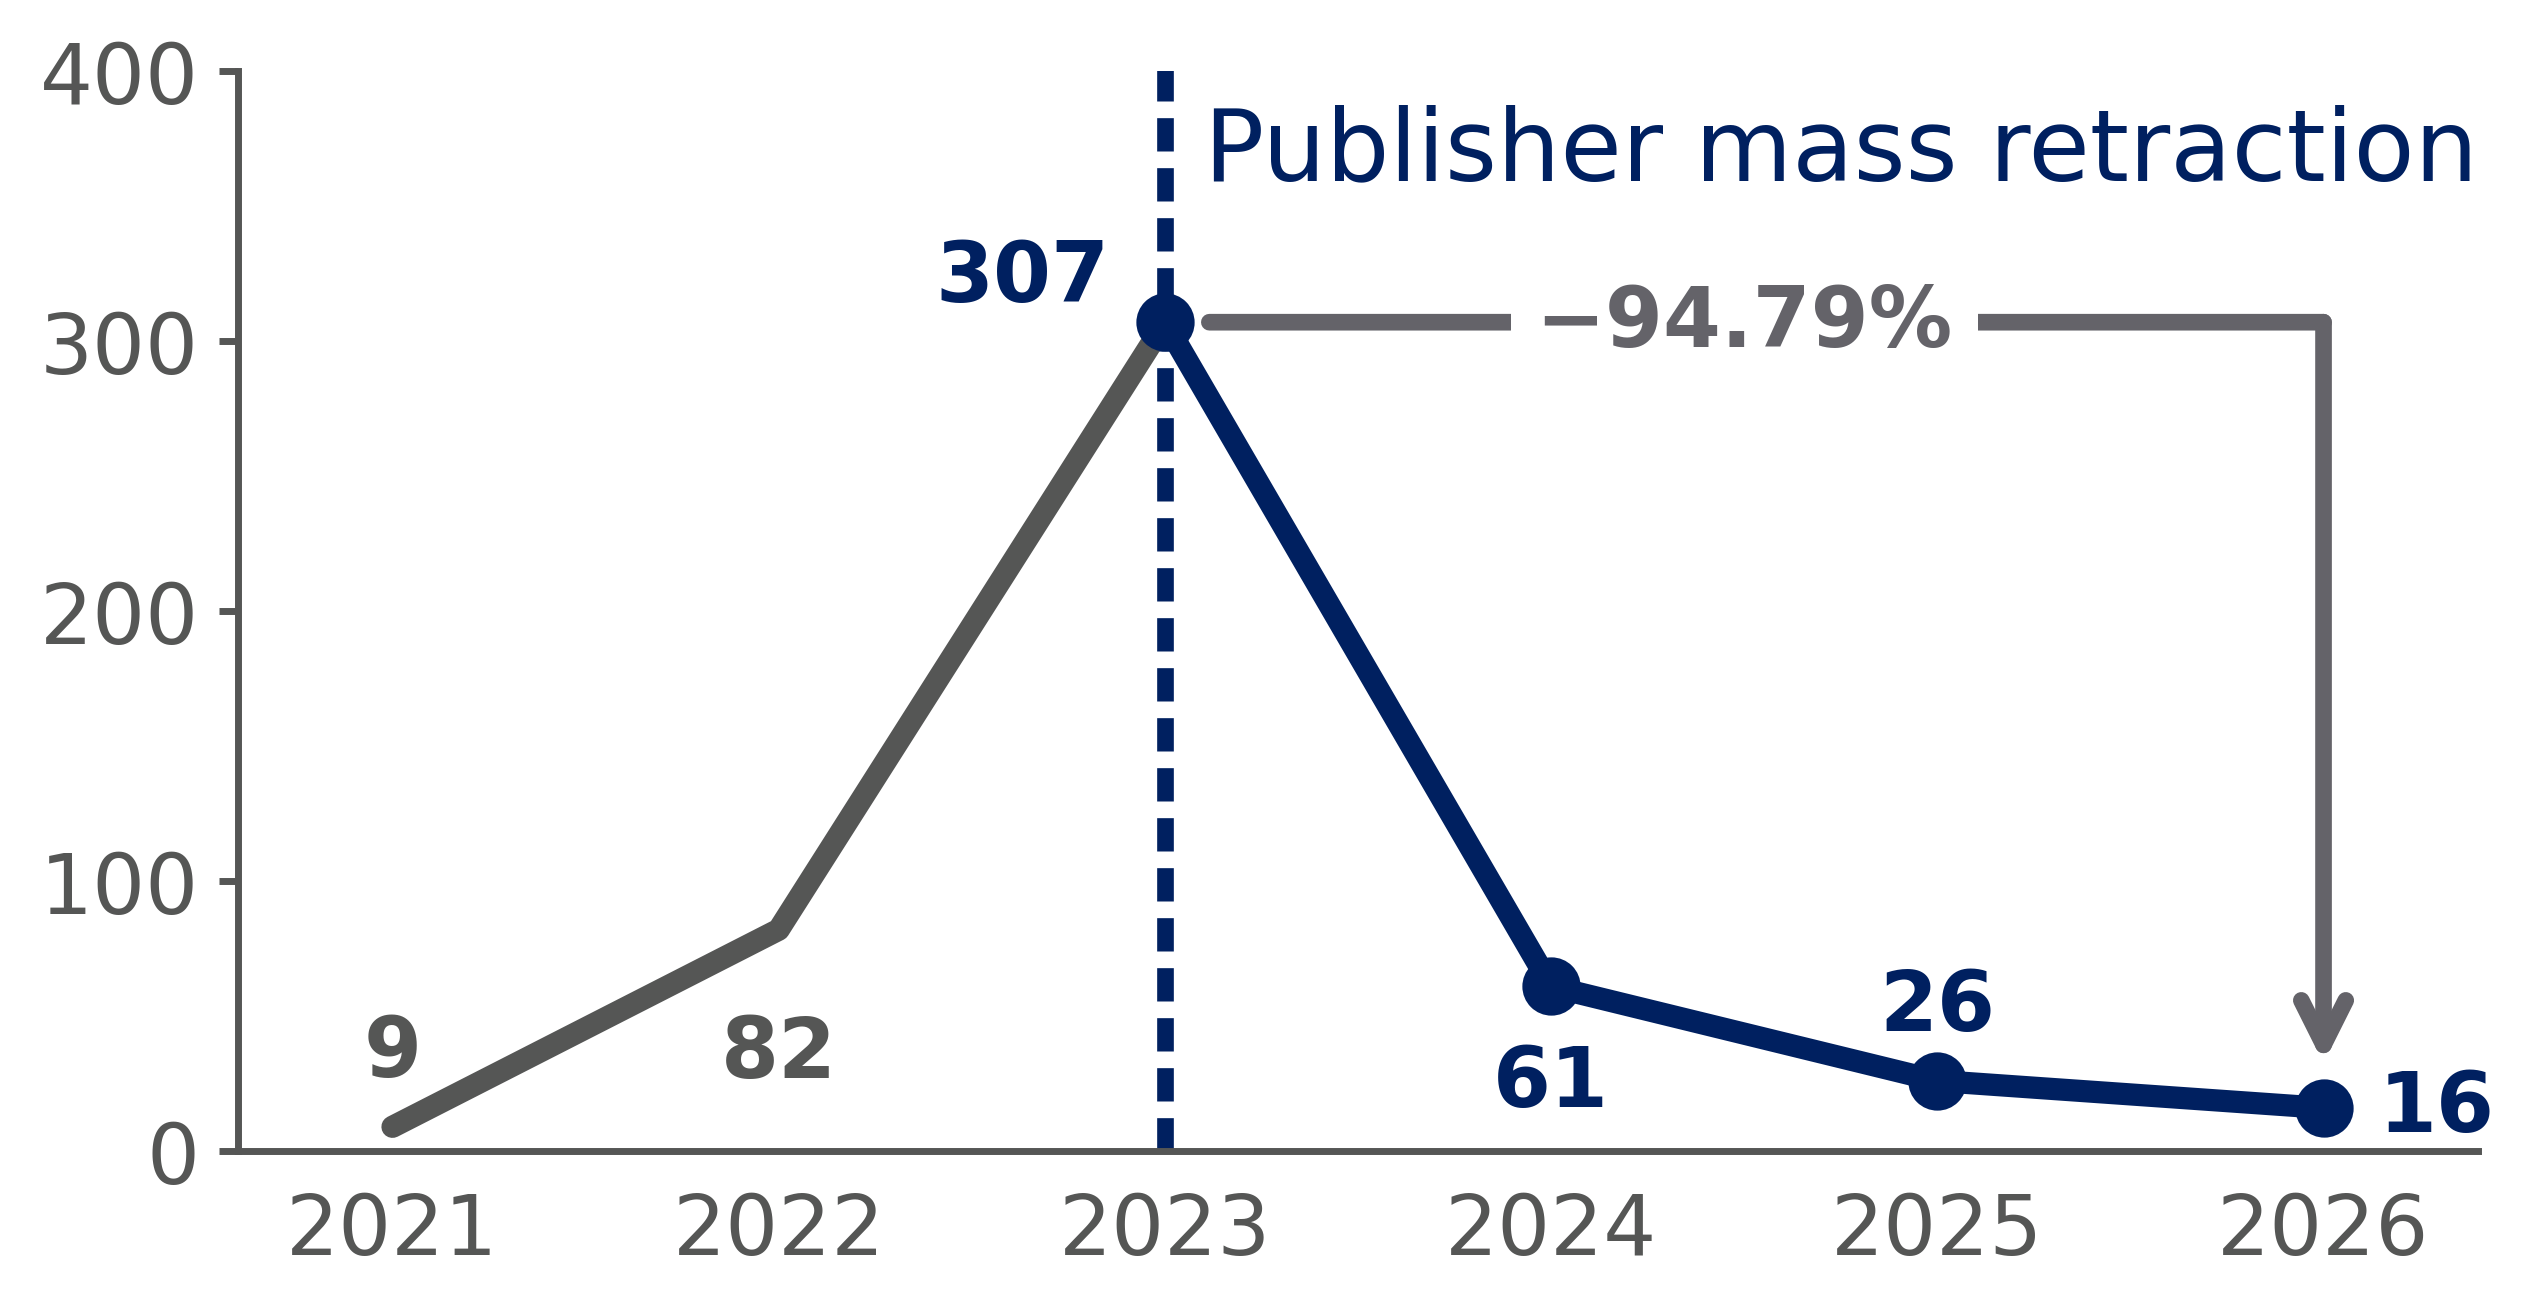

In [80]:
%run src/plotting_styles.py
%run src/plots/volume-by-year.py

fig, ax = render_retraction_chart(
    retraction_by_year,
    palette=PALETTE,
    annotation_positions=ANNOTATION_POSITIONS
)
plt.show()